**Chapter 14 – Deep Computer Vision Using Convolutional Neural Networks**

In this chapter, we will explore the world of deep computer vision using **convolutional neural networks (CNNs)**. CNNs have revolutionized the field of computer vision and have been instrumental in achieving state-of-the-art results in various tasks such as image classification, object detection, and image segmentation.

_This notebook contains all the sample code and solutions to the exercises in chapter 14._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
  </td>
  <td>
    <a target="_blank" href="https://kaggle.com/kernels/welcome?src=https://github.com/ageron/handson-ml3/blob/main/14_deep_computer_vision_with_cnns.ipynb"><img src="https://kaggle.com/static/images/open-in-kaggle.svg" /></a>
  </td>
</table>

# Setup

This project requires Python 3.7 or above:

In [14]:
import sys

assert sys.version_info >= (3, 7)

It also requires Scikit-Learn ≥ 1.0.1:

In [15]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

And TensorFlow ≥ 2.8:

In [16]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

As we did in earlier chapters, let's define the default font sizes to make the figures prettier:

In [17]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

This chapter can be very slow without a GPU, so let's make sure there's one, or else issue a warning:

In [18]:
# Is this notebook running on Colab or Kaggle?
IS_COLAB = "google.colab" in sys.modules
IS_KAGGLE = "kaggle_secrets" in sys.modules

if not tf.config.list_physical_devices('GPU'):
    print("No GPU was detected. Neural nets can be very slow without a GPU.")
    if IS_COLAB:
        print("Go to Runtime > Change runtime and select a GPU hardware "
              "accelerator.")
    if IS_KAGGLE:
        print("Go to Settings > Accelerator and select GPU.")

No GPU was detected. Neural nets can be very slow without a GPU.


---

# Convolutional Layers
## Implementing Convolutional Layers With Keras

Let's load two sample images, rescale their pixel values to 0-1, and center crop them to small 70×120 images:

In [42]:
from sklearn.datasets import load_sample_images
import tensorflow as tf

images = load_sample_images()["images"]
images = tf.keras.layers.CenterCrop(height=70, width=120)(images)
images = tf.keras.layers.Rescaling(scale=1 / 255)(images)

In [43]:
images.shape

TensorShape([2, 70, 120, 3])

In [44]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7)
fmaps = conv_layer(images)

In [45]:
fmaps.shape

TensorShape([2, 64, 114, 32])

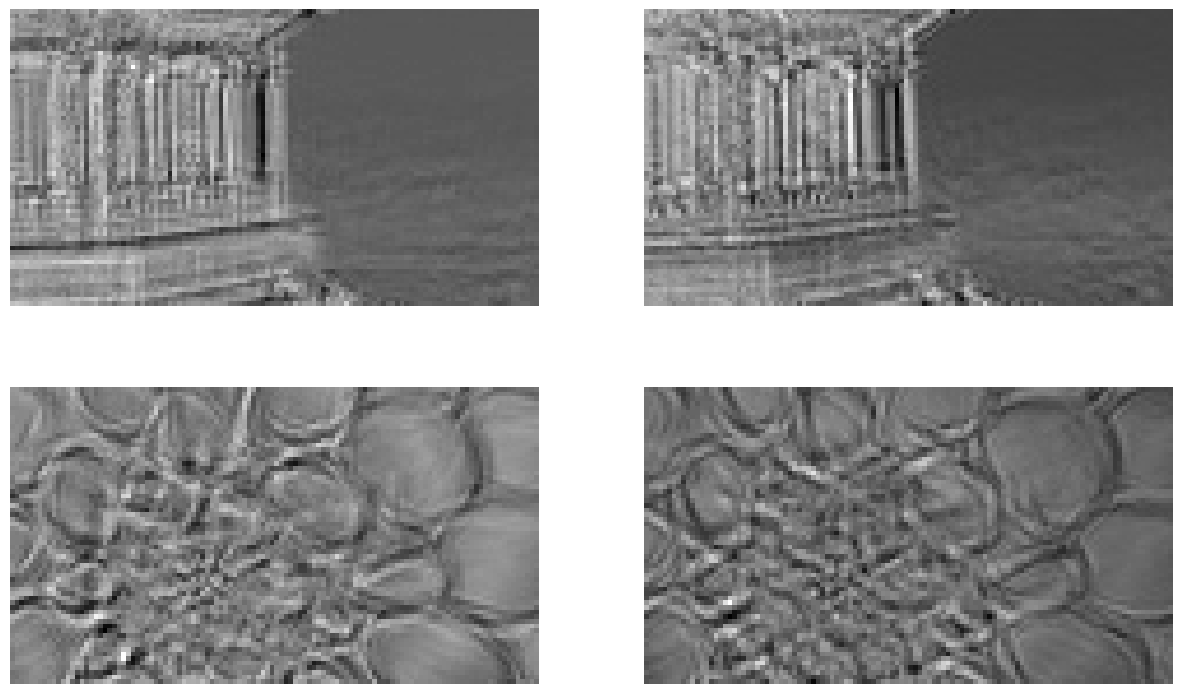

In [46]:
# extra code – displays the two output feature maps for each image

plt.figure(figsize=(15, 9))
for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

As you can see, randomly generated filters typically act like edge detectors, which is great since that's a useful tool in image processing, and that's the type of filters that a convolutional layer typically starts with. Then, during training, it gradually learns improved filters to recognize useful patterns for the task.

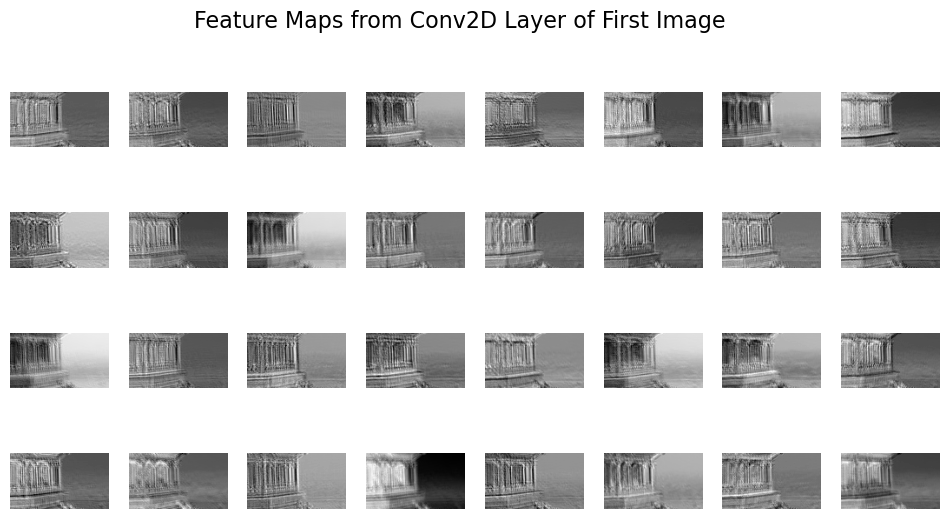

In [47]:
# extra code – displays all 32 feature maps for the first image
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(fmaps[0, :, :, i], cmap="gray")
    plt.axis("off")
plt.suptitle("Feature Maps from Conv2D Layer of First Image", fontsize=16)
plt.show()

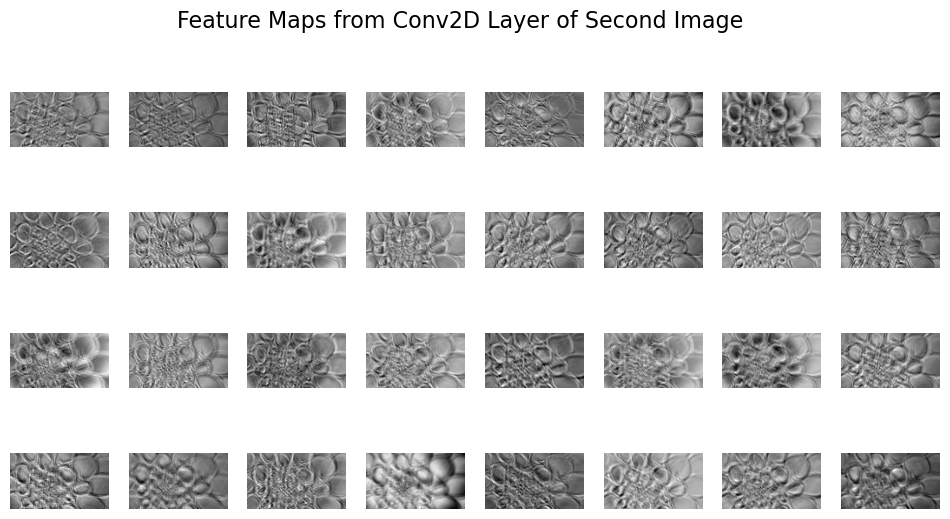

In [48]:
# extra code – displays all 32 feature maps for the second image
plt.figure(figsize=(12, 6))
for i in range(32):
    plt.subplot(4, 8, i + 1)
    plt.imshow(fmaps[1, :, :, i], cmap="gray")
    plt.axis("off")
plt.suptitle("Feature Maps from Conv2D Layer of Second Image", fontsize=16)
plt.show()

Now let's use zero-padding:

In [49]:
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7,
                                    padding="same") # added padding="same" to preserve spatial dimensions
fmaps = conv_layer(images)

In [50]:
fmaps.shape

TensorShape([2, 70, 120, 32])

Moreover, by setting the `strides` hyperparameter, we can make the convolutional layer skip some pixels, which reduces the spatial dimensions of the output feature maps. For example, setting `strides=2` will reduce the width and height of the output by half (if `padding="same"` is used):

In [51]:
# extra code – shows that the output shape when we set strides=2
conv_layer = tf.keras.layers.Conv2D(filters=32, kernel_size=7, padding="same",
                                    strides=2)
fmaps = conv_layer(images)
fmaps.shape

TensorShape([2, 35, 60, 32])

In [52]:
# extra code – this utility function can be useful to compute the size of the
#              feature maps output by a convolutional layer. It also returns
#              the number of ignored rows or columns if padding="valid", or the
#              number of zero-padded rows or columns if padding="same"."""

import numpy as np

def conv_output_size(input_size, kernel_size, strides=1, padding="valid"):
    if padding=="valid":
        z = input_size - kernel_size + strides
        output_size = z // strides
        num_ignored = z % strides
        return output_size, num_ignored
    else:
        output_size = (input_size - 1) // strides + 1
        num_padded = (output_size - 1) * strides + kernel_size - input_size
        return output_size, num_padded

conv_output_size(np.array([70, 120]), kernel_size=7, strides=2, padding="same")

(array([35, 60]), array([5, 5]))

Let's now look at the weights:

In [53]:
kernels, biases = conv_layer.get_weights()
kernels.shape

(7, 7, 3, 32)

In [54]:
biases.shape

(32,)

In [55]:
# extra code – shows how to use the tf.nn.conv2d() operation

tf.random.set_seed(42)
filters = tf.random.normal([7, 7, 3, 2])
biases = tf.zeros([2])
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

Let's manually create two filters full of zeros, except for a vertical line of 1s in the first filter, and a horizontal one in the second filter (just like in Figure 14–5). The two output feature maps highlight vertical lines and horizontal lines, respectively. In practice you will probably never need to create filters manually, since the convolutional layers will learn them automatically.

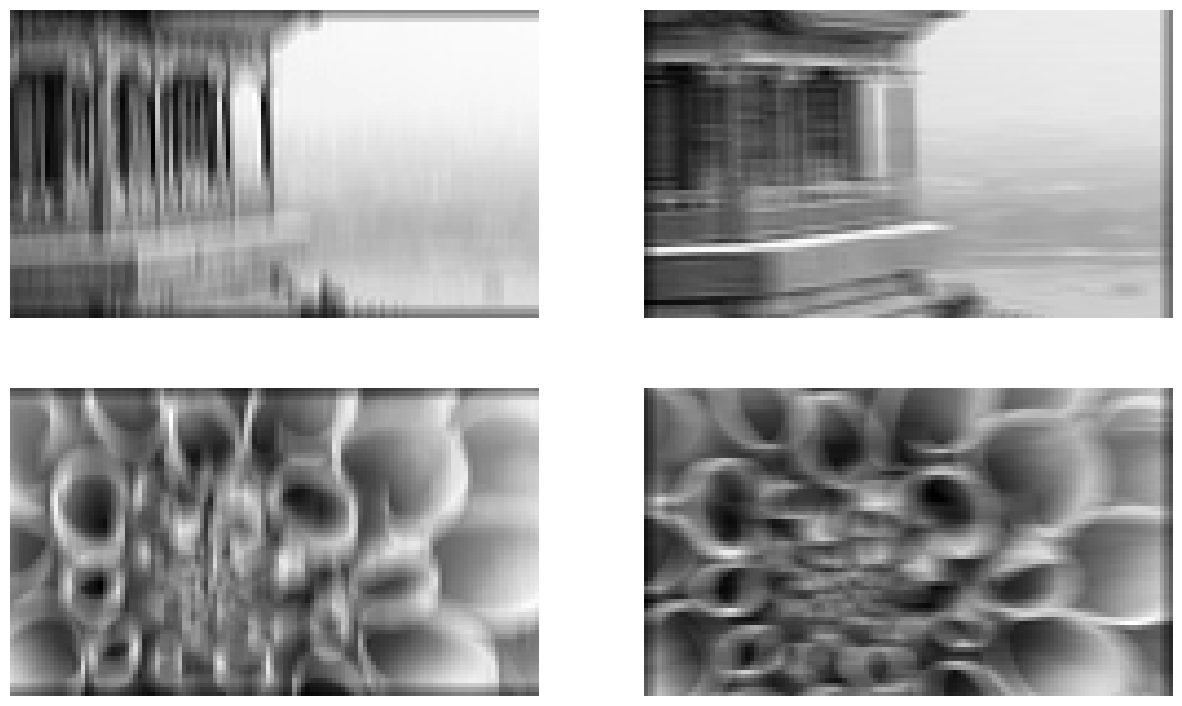

In [56]:
# extra code – shows how to manually create two filters to get images similar
#              to those in Figure 14–5.

plt.figure(figsize=(15, 9))
filters = np.zeros([7, 7, 3, 2])
filters[:, 3, :, 0] = 1
filters[3, :, :, 1] = 1
fmaps = tf.nn.conv2d(images, filters, strides=1, padding="SAME") + biases

for image_idx in (0, 1):
    for fmap_idx in (0, 1):
        plt.subplot(2, 2, image_idx * 2 + fmap_idx + 1)
        plt.imshow(fmaps[image_idx, :, :, fmap_idx], cmap="gray")
        plt.axis("off")

plt.show()

Notice the dark lines at the top and bottom of the two images on the left, and on the left and right of the two images on the right? Can you guess what these are? Why were they not present in the previous figure?

You guessed it! These are artifacts due to the fact that we used zero padding in this case, while we did not use zero padding to create the feature maps in the previous figure. Because of zero padding, the two feature maps based on the vertical line filter (i.e., the two left images) could not fully activate near the top and bottom of the images. Similarly, the two feature maps based on the horizontal line filter (i.e., the two right images) could not fully activate near the left and right of the images.

---

# Pooling Layers
## Implementing Pooling Layers With Keras

Let's load the same two sample images as before, and apply a max pooling layer to them:

**Max pooling**

In [57]:
max_pool = tf.keras.layers.MaxPool2D(pool_size=2)

In [58]:
output = max_pool(images)

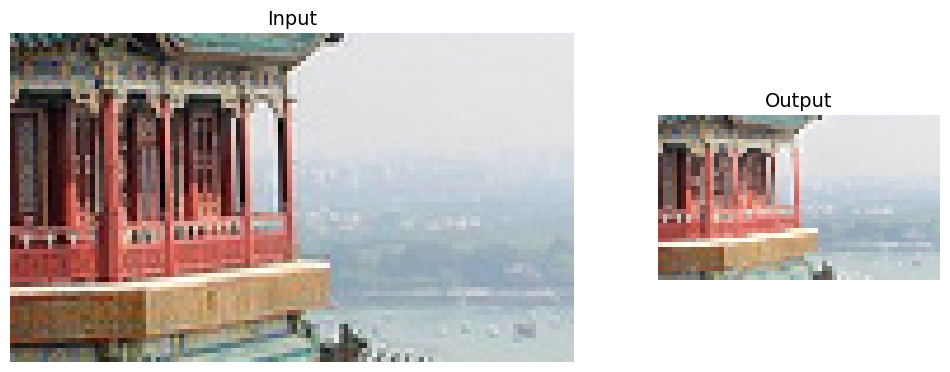

In [59]:
# extra code – this cells shows what max pooling with stride = 2 looks like

import matplotlib as mpl

fig = plt.figure(figsize=(12, 8))
gs = mpl.gridspec.GridSpec(nrows=1, ncols=2, width_ratios=[2, 1])

ax1 = fig.add_subplot(gs[0, 0])
ax1.set_title("Input")
ax1.imshow(images[0])  # plot the 1st image
ax1.axis("off")
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_title("Output")
ax2.imshow(output[0])  # plot the output for the 1st image
ax2.axis("off")
plt.show()

`MaxPooling2D` is the most common type of pooling layer. It simply outputs the maximum value in each patch of the feature map. For example, if you use a 2×2 max pooling layer with `strides=2`, it will output the maximum value in each non-overlapping 2×2 patch of the input feature map, effectively reducing the width and height of the output by half.

**Depth-wise pooling**

In [60]:
# extra code – shows how to use the max_pool() op; only works on the CPU
np.random.seed(42)
fmaps = np.random.rand(2, 70, 120, 60)
with tf.device("/cpu:0"):
    output = tf.nn.max_pool(fmaps, ksize=(1, 1, 1, 3), strides=(1, 1, 1, 3),
                            padding="VALID")
output.shape

TensorShape([2, 70, 120, 20])

Below, we implement a custom Keras layer for depth-wise pooling. Unlike standard `MaxPool2D` which pools spatially, this layer pools across the channel dimension. It computes the maximum value across groups of feature maps at each spatial location. For instance, if you have 60 feature maps, and `pool_size` is 3, it will produce 20 feature maps, where each pixel in an output feature map is the maximum value from a group of 3 input feature maps at the corresponding spatial location.

In [61]:
class DepthPool(tf.keras.layers.Layer):
    def __init__(self, pool_size=2, **kwargs):
        super().__init__(**kwargs)
        self.pool_size = pool_size
    
    def call(self, inputs):
        shape = tf.shape(inputs)  # shape[-1] is the number of channels
        groups = shape[-1] // self.pool_size  # number of channel groups
        # Reshape to group channels and then take the maximum along the channel groups.
        # This implicitly handles "VALID" padding for the channels dimension.
        new_shape = tf.concat([shape[:-1], [groups, self.pool_size]], axis=0)
        return tf.reduce_max(tf.reshape(inputs, new_shape), axis=-1)

In [62]:
# extra code – shows that this custom layer gives the same result as max_pool()
np.allclose(DepthPool(pool_size=3)(fmaps), output)

True

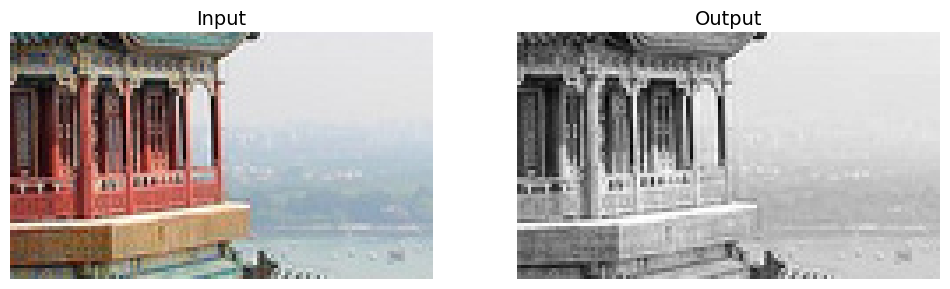

In [63]:
# extra code – computes and displays the output of the depthwise pooling layer

depth_output = DepthPool(pool_size=3)(images)

plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.title("Input")
plt.imshow(images[0])  # plot the 1st image
plt.axis("off")
plt.subplot(1, 2, 2)
plt.title("Output")
plt.imshow(depth_output[0, ..., 0], cmap="gray")  # plot 1st image's output
plt.axis("off")
plt.show()

The original input image has 3 channels (Red, Green, Blue), and the output feature map has 1 channel, which is the maximum value across the three input channels at each spatial location.

**Global Average Pooling**

`GlobalAveragePooling2D` is a special type of pooling layer that computes *the average value of each feature map across its entire spatial dimensions*. For example, if you have 60 feature maps of size 10×10, `GlobalAveragePooling2D` will output a single value for each feature map, resulting in a 60-dimensional vector. This is often used at the end of a convolutional neural network before the final classification layer, as it reduces the spatial dimensions to a single value per feature map while retaining the depth information.

In [64]:
global_avg_pool = tf.keras.layers.GlobalAvgPool2D()

The following layer is equivalent:

In [65]:
global_avg_pool = tf.keras.layers.Lambda(
    lambda X: tf.reduce_mean(X, axis=[1, 2]))

It creates a Keras layer that performs global average pooling over the spatial dimensions of a 4D tensor.

`tf.keras.layers.Lambda(...)` wraps a small custom operation as a layer. Inside it, `lambda X: tf.reduce_mean(X, axis=[1, 2])` computes the mean across the height and width axes of the input tensor. For a typical convolutional output with shape `[batch, height, width, channels]`, this reduces each feature map to a single number, producing output shape `[batch, channels]`.

In other words, the layer collapses each channel’s spatial map into its average value, while preserving the batch and channel dimensions. This is a common way to convert convolutional feature maps into a vector before a dense classifier, and it is known as global average pooling.

In [66]:
global_avg_pool(images)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[0.64338624, 0.5971759 , 0.5824972 ],
       [0.76306933, 0.2601113 , 0.10849128]], dtype=float32)>

It shows the result of calling the pooling layer on a batch of two images. TensorFlow prints it as a `tf.Tensor` with shape `(2, 3)`, meaning there are two examples in the batch and three output values per example.

Each value is a floating-point mean computed over the spatial dimensions of one channel or feature map. In other words, the layer collapsed each image’s height and width into a single average per channel, so the output is one 3-dimensional vector for each of the two input images.

---
# CNN Architectures

**Tackling Fashion MNIST With a CNN**

In [17]:
# extra code – loads the mnist dataset, add the channels axis to the inputs,
#              scales the values to the 0-1 range, and splits the dataset
import numpy as np

mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = np.expand_dims(X_train_full, axis=-1).astype(np.float32) / 255
X_test = np.expand_dims(X_test.astype(np.float32), axis=-1) / 255
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

First, we define `DefaultConv2D`, which is a convenient wrapper around `Conv2D` that sets some default hyperparameters (e.g., `kernel_size=3`, `padding="same"`, `activation="relu"`, and `kernel_initializer="he_normal"`):

Second, we compose the model using `DefaultConv2D` layers, followed by a `MaxPooling2D` layer, and finally a `Flatten` layer and a `Dense` output layer:

In [6]:
from functools import partial

tf.random.set_seed(42)  # extra code – ensures reproducibility
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, padding="same",
                        activation="relu", kernel_initializer="he_normal")
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[28, 28, 1]),
    DefaultConv2D(filters=64, kernel_size=7),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=128),
    DefaultConv2D(filters=128),
    tf.keras.layers.MaxPool2D(),
    DefaultConv2D(filters=256),
    DefaultConv2D(filters=256),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(units=128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=64, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(units=10, activation="softmax")
])

In [20]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 64)     │         3,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 7, 7, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,413,834 (5.39 MB)

 Trainable params: 1,413,834 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

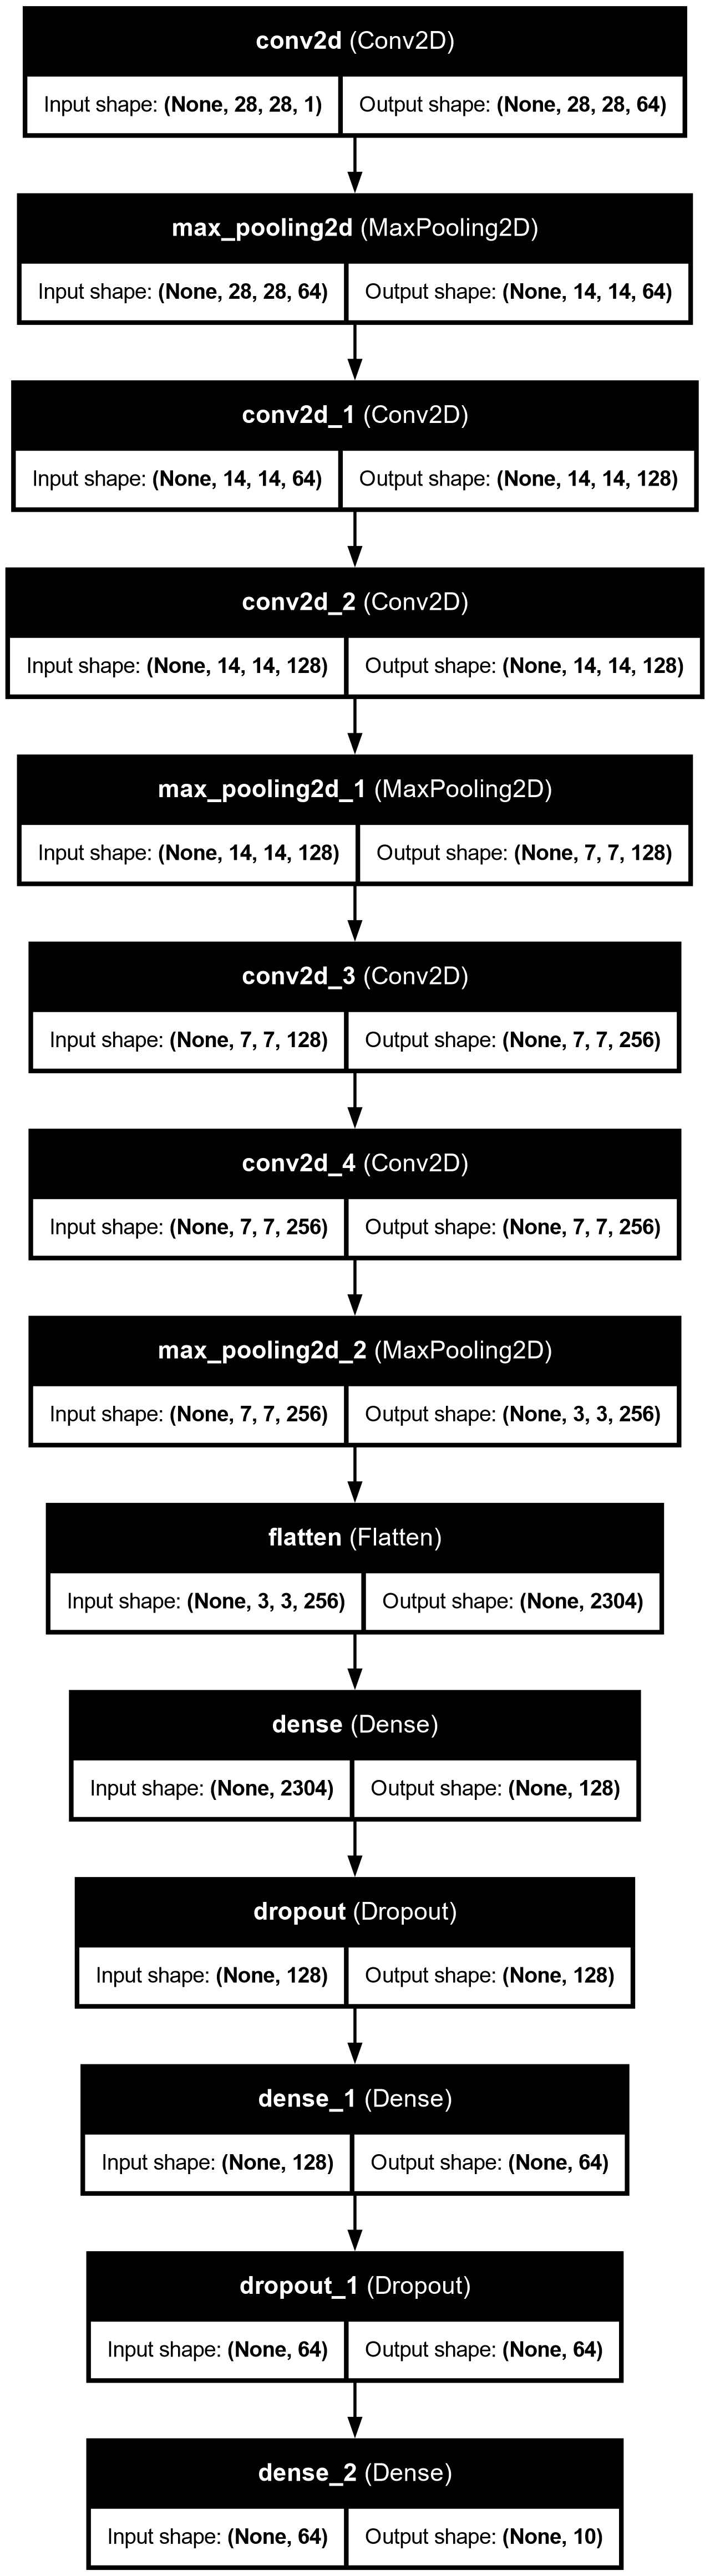

In [22]:
# Visualize the model architecture using plot_model() (requires pydot and graphviz)
tf.keras.utils.plot_model(model, show_shapes=True, show_layer_names=True)

In [23]:
# extra code – compiles, fits, evaluates, and uses the model to make predictions
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])
history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_valid, y_valid))
score = model.evaluate(X_test, y_test)
X_new = X_test[:10]  # pretend we have new images
y_pred = model.predict(X_new)

Epoch 1/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 131s 75ms/step - accuracy: 0.7571 - loss: 0.6954 - val_accuracy: 0.8688 - val_loss: 0.3488
Epoch 2/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 137s 80ms/step - accuracy: 0.8656 - loss: 0.4038 - val_accuracy: 0.8890 - val_loss: 0.3121
Epoch 3/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 154s 89ms/step - accuracy: 0.8855 - loss: 0.3389 - val_accuracy: 0.9008 - val_loss: 0.2715
Epoch 4/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 154s 90ms/step - accuracy: 0.8992 - loss: 0.2997 - val_accuracy: 0.9050 - val_loss: 0.2667
Epoch 5/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 151s 88ms/step - accuracy: 0.9062 - loss: 0.2758 - val_accuracy: 0.9062 - val_loss: 0.2699
Epoch 6/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 152s 88ms/step - accuracy: 0.9133 - loss: 0.2529 - val_accuracy: 0.8986 - val_loss: 0.2865
Epoch 7/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 152s 88ms/step - accuracy: 0.9164 - loss: 0.2424 - val_accuracy: 0.9128 - val_loss: 0.2685
Epoch 8/10
1719/1719 ━━━━━━━━━━━━━━━━━━━━ 151s 88ms/step - accuracy: 

In [29]:
tf.argmax(y_pred, axis=1).numpy().astype(np.uint8), y_test[:10]

(array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8),
 array([9, 2, 1, 1, 6, 1, 4, 6, 5, 7], dtype=uint8))

## LeNet-5

The famous LeNet-5 architecture had the following layers:

Layer  | Type            | Maps | Size     | Kernel size | Stride | Activation
-------|-----------------|------|----------|-------------|--------|-----------
 Out   | Fully connected | –    | 10       | –           | –      | RBF
 F6    | Fully connected | –    | 84       | –           | –      | tanh
 C5    | Convolution     | 120  | 1 × 1    | 5 × 5       | 1      | tanh
 S4    | Avg pooling     | 16   | 5 × 5    | 2 × 2       | 2      | tanh
 C3    | Convolution     | 16   | 10 × 10  | 5 × 5       | 1      | tanh
 S2    | Avg pooling     | 6    | 14 × 14  | 2 × 2       | 2      | tanh
 C1    | Convolution     | 6    | 28 × 28  | 5 × 5       | 1      | tanh
 In    | Input           | 1    | 32 × 32  | –           | –      | –

There were a few tweaks here and there, which don't really matter much anymore, but in case you are interested, here they are:

* MNIST images are 28 × 28 pixels, but they are zero-padded to 32 × 32 pixels and normalized before being fed to the network. The rest of the network does not use any padding, which is why the size keeps shrinking as the image progresses through the network.
* The average pooling layers are slightly more complex than usual: each neuron computes the mean of its inputs, then multiplies the result by a learnable coefficient (one per map) and adds a learnable bias term (again, one per map), then finally applies the activation function.
* Most neurons in C3 maps are connected to neurons in only three or four S2 maps (instead of all six S2 maps). See table 1 (page 8) in the [original paper](https://homl.info/lenet5) for details.
* The output layer is a bit special: instead of computing the matrix multiplication of the inputs and the weight vector, each neuron outputs the square of the Euclidian distance between its input vector and its weight vector. Each output measures how much the image belongs to a particular digit class. The cross-entropy cost function is now preferred, as it penalizes bad predictions much more, producing larger gradients and converging faster.

---

# Implementing a ResNet-34 CNN Using Keras

`ResNet-34` is a popular convolutional neural network architecture that consists of 34 layers, including convolutional layers, batch normalization layers, and **skip connections (also known as residual connections)**. The skip connections allow the network to learn residual functions, which helps to mitigate the vanishing gradient problem and allows for training deeper networks effectively. 

The architecture is organized into several blocks, each containing multiple convolutional layers followed by batch normalization and ReLU activation functions. The network ends with a global average pooling layer and a fully connected layer for classification. ResNet-34 is widely used for image classification tasks and has achieved state-of-the-art performance on various benchmarks.

In [3]:
import tensorflow as tf
from functools import partial
DefaultConv2D = partial(tf.keras.layers.Conv2D, kernel_size=3, strides=1,
                        padding="same", kernel_initializer="he_normal",
                        use_bias=False) # added use_bias=False since we will be using BatchNormalization, which has its own bias term

class ResidualUnit(tf.keras.layers.Layer):
    """A residual unit with two convolutional layers and a skip connection. If the strides are greater than 1, then the skip connection also includes a convolutional layer to match the dimensions. The activation function is applied after adding the main path and the skip path."""
    def __init__(self, filters, strides=1, activation="relu", **kwargs):
        super().__init__(**kwargs)
        self.activation = tf.keras.activations.get(activation)

        # The main path consists of two convolutional layers, each followed by batch normalization and an activation function. The first convolutional layer uses the specified strides, while the second one uses a stride of 1.
        self.main_layers = [
            DefaultConv2D(filters, strides=strides),
            tf.keras.layers.BatchNormalization(),
            self.activation,
            DefaultConv2D(filters),
            tf.keras.layers.BatchNormalization()
        ]
        # The skip path is empty if strides=1, otherwise it consists of a convolutional layer followed by batch normalization to match the dimensions of the main path's output.
        self.skip_layers = []
        if strides > 1:
            self.skip_layers = [
                DefaultConv2D(filters, kernel_size=1, strides=strides),
                tf.keras.layers.BatchNormalization()
            ]

    def call(self, inputs):
        """ The call() method applies the main path layers to the inputs, then applies the skip path layers to the inputs, and finally adds the outputs of the main path and the skip path together and applies the activation function to the result."""
        Z = inputs
        for layer in self.main_layers:
            Z = layer(Z)
        skip_Z = inputs
        for layer in self.skip_layers:
            skip_Z = layer(skip_Z)
        return self.activation(Z + skip_Z)

Above is the implementation of the `ResidualUnit` class, which represents a single residual unit in the ResNet architecture. It consists of two convolutional layers with batch normalization and an optional skip connection that allows the input to bypass the convolutional layers and be added to their output.
 
The `call` method defines how the input is processed through the main path and the skip path, and how the outputs are combined and activated.

Then, we can build the ResNet-34 architecture by stacking multiple `ResidualUnit` layers together, along with the initial convolutional layer, batch normalization, and max pooling layers. Finally, we add a global average pooling layer and a fully connected layer for classification.

In [5]:
# Build the ResNet-34 model
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=[224, 224, 3]),          # Input: 224x224 RGB image
    DefaultConv2D(64, kernel_size=7, strides=2),         # Initial conv layer: 64 filters, downsample by 2
    tf.keras.layers.BatchNormalization(),                # Normalize activations for stable training
    tf.keras.layers.Activation("relu"),                  # Nonlinearity after batch norm
    tf.keras.layers.MaxPool2D(pool_size=3, strides=2,
                              padding="same"),            # Reduce spatial size again while preserving shape
])

# Add the residual stages
prev_filters = 64
for filters in [64] * 3 + [128] * 4 + [256] * 6 + [512] * 3:
    # Downsample when the number of filters increases
    strides = 1 if filters == prev_filters else 2
    model.add(ResidualUnit(filters, strides=strides))
    prev_filters = filters

# Final classification head
model.add(tf.keras.layers.GlobalAvgPool2D())             # Global average pooling over height and width
model.add(tf.keras.layers.Flatten())                     # Flatten to a vector for the dense layer
model.add(tf.keras.layers.Dense(10, activation="softmax"))  # Output: 10-class softmax

---
# Using Pretrained Models from Keras

In practice, you will often want to use a pretrained model, such as ResNet50, which is a deeper version of ResNet-34 with 50 layers. Keras provides several pretrained models in the `keras.applications` module, which you can easily load and use for your own tasks. For example, you can load the ResNet50 model pretrained on ImageNet as follows:

In [6]:
model = tf.keras.applications.ResNet50(weights="imagenet")

**Warning**: The expression `load_sample_images()["images"]` returns a Python list of images. However, in the latest versions, Keras does not accept Python lists anymore, so we must convert this list to a tensor. We can do this using `tf.constant()`, but here I have used `K.constant()` instead: it simply calls `tf.constant()` if you are using TensorFlow as the backend (as is the case here), but if you ever decide to use JAX or PyTorch as the backend instead, `K.constant()` will call the appropriate function from the chosen backend.

In [7]:
from sklearn.datasets import load_sample_images

K = tf.keras.backend
img_raw = load_sample_images()["images"]
images = K.constant(img_raw)
images_resized = tf.keras.layers.Resizing(height=224, width=224,
                                          crop_to_aspect_ratio=True)(images)

In [8]:
type(img_raw), type(images)

(list, tensorflow.python.framework.ops.EagerTensor)

If you want to use PyTorch, you should not rely on `tf.keras.backend` helpers. In PyTorch you convert the Python list to a tensor using `torch.tensor()` or `torch.from_numpy()`, not `K.constant()`.

For example:



```python 
import torch
from sklearn.datasets import load_sample_images

images = load_sample_images()["images"]
images = torch.stack([torch.from_numpy(img).float() / 255.0 for img in images])
```



If you are using a backend-agnostic Keras implementation and you actually switch its backend to PyTorch, then `K.constant()` would internally use the PyTorch equivalent. But in practice, standard TensorFlow/Keras code and PyTorch code are separate, so for PyTorch use native `torch` APIs.

Image 0 shape: (224, 224, 3), dtype: <dtype: 'float32'>
Pixel value range: [0.0, 255.0]




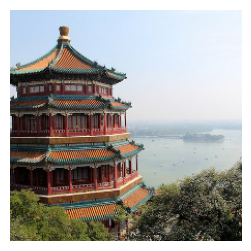

Image 1 shape: (224, 224, 3), dtype: <dtype: 'float32'>
Pixel value range: [0.0, 252.569091796875]




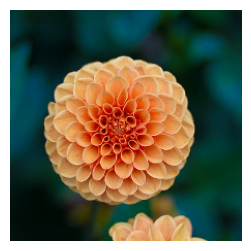

In [9]:
import numpy as np

# Inspect the resized images
for i, img in enumerate(images_resized):
    print(f"Image {i} shape: {img.shape}, dtype: {img.dtype}")
    print(f"Pixel value range: [{tf.reduce_min(img).numpy()}, {tf.reduce_max(img).numpy()}]")
    print("\n")
    # extra code – shows the resized images
    plt.figure(figsize=(6, 3))
    plt.imshow(img.numpy().astype(np.uint8))
    plt.axis("off")
    plt.show()

It is noted that the `preprocess_input()` function is specific to the pretrained model and applies the necessary preprocessing steps to the input images, such as **scaling pixel values** and **rearranging color channels**, to ensure that the input data is in the correct format for the model to make accurate predictions.

For ResNet50, `preprocess_input()` typically scales and centers pixel values and rearranges color channels as needed, so the input tensor matches the training preprocessing used for the pretrained ImageNet weights. The result is stored in inputs, ready to be fed into the ResNet50 model for prediction.

In [10]:
inputs = tf.keras.applications.resnet50.preprocess_input(images_resized)

In [11]:
Y_proba = model.predict(inputs) # computes the predicted probabilities for each class
Y_proba.shape

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


(2, 1000)

In [20]:
model.layers[-1].__class__.__name__, model.output_shape

('Dense', (None, 1000))

In [13]:
print("Predicted classes:", tf.argmax(Y_proba, axis=1).numpy())


Predicted classes: [698 883]


In [14]:
top_K = tf.keras.applications.resnet50.decode_predictions(Y_proba, top=3) # decodes the predicted probabilities to get the top 3 predicted classes and their probabilities for each image

for image_index in range(len(images)):
    print(f"Image #{image_index}")
    for class_id, name, y_proba in top_K[image_index]:
        print(f"  {class_id} - {name:12s} {y_proba:.2%}")

35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
Image #0
  n03877845 - palace       54.69%
  n03781244 - monastery    24.71%
  n02825657 - bell_cote    18.55%
Image #1
  n04522168 - vase         32.67%
  n11939491 - daisy        17.82%
  n03530642 - honeycomb    12.04%


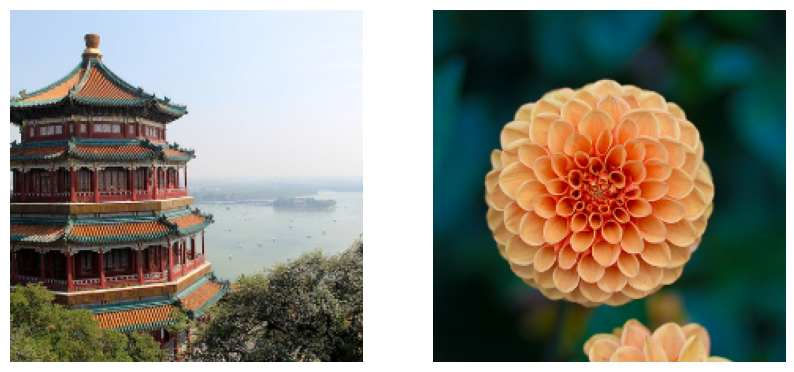

In [15]:
# extra code – displays the cropped and resized images

plt.figure(figsize=(10, 6))
for idx in (0, 1):
    plt.subplot(1, 2, idx + 1)
    plt.imshow(images_resized[idx] / 255)
    plt.axis("off")

plt.show()

---
# Pretrained Models for Transfer Learning

**Transfer learning** is a powerful technique in deep learning where you take a pretrained model (e.g., ResNet50 trained on ImageNet) and fine-tune it on a new, often smaller, dataset for a different but related task. This allows you to leverage the knowledge the model has already learned from the large dataset, which can lead to faster convergence and improved performance on the new task.

In the following, we use the TensorFlow Datasets API to load the `tf_flowers` dataset, which contains images of flowers belonging to five different classes. We will use a pretrained ResNet50 model as a feature extractor and fine-tune it on this dataset to classify the flower images.

In [19]:
import tensorflow_datasets as tfds

dataset, info = tfds.load("tf_flowers", as_supervised=True, with_info=True)

In [20]:
type(dataset)

dict

In [21]:
dataset.keys()

dict_keys(['train'])

In [22]:
dataset["train"]

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [23]:
info

tfds.core.DatasetInfo(
    name='tf_flowers',
    full_name='tf_flowers/3.0.1',
    description="""
    A large set of images of flowers
    """,
    homepage='https://www.tensorflow.org/tutorials/load_data/images',
    data_dir='C:\\Users\\yuanh\\tensorflow_datasets\\tf_flowers\\3.0.1',
    file_format=tfrecord,
    download_size=218.21 MiB,
    dataset_size=221.83 MiB,
    features=FeaturesDict({
        'image': Image(shape=(None, None, 3), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=5),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'train': <SplitInfo num_examples=3670, num_shards=2>,
    },
    citation="""@ONLINE {tfflowers,
    author = "The TensorFlow Team",
    title = "Flowers",
    month = "jan",
    year = "2019",
    url = "http://download.tensorflow.org/example_images/flower_photos.tgz" }""",
)

In [24]:
dataset_size = info.splits["train"].num_examples
class_names = info.features["label"].names
n_classes = info.features["label"].num_classes

- `as_supervised=True` means that the dataset will be returned as a tuple of (input, label) pairs, which is convenient for supervised learning tasks.
- `with_info=True` means that the dataset will also return a dictionary containing metadata about the dataset, such as the number of classes and the shape of the images.

In [25]:
dataset_size

3670

In [26]:
class_names

['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']

In [27]:
n_classes

5

Now, let's use tfds.load() to load the `tf_flowers` dataset and split it into training, validation, and test sets. We will use the `split` argument to specify the proportions for each set, and the `as_supervised=True` argument to get the data as (input, label) pairs.

In [28]:
test_set_raw, valid_set_raw, train_set_raw = tfds.load(
    "tf_flowers",
    split=["train[:10%]", "train[10%:25%]", "train[25%:]"],
    as_supervised=True)

By setting `split=["train[:10%]", "train[10%:25%]", "train[25%:]"]`, we are instructing TensorFlow Datasets to divide the `tf_flowers` dataset into three parts: the first 10% of the data will be used as the test set, the next 15% will be used as the validation set, and the remaining 75% will be used as the training set. This allows us to have separate datasets for training, validating, and testing our model.

The `as_supervised=True` argument means that each example in the dataset will be returned as a tuple of (input, label) pairs, which is convenient for supervised learning tasks. This way, when we iterate over the dataset, we will get both the images and their corresponding labels, making it easier to feed them into our model for training and evaluation.

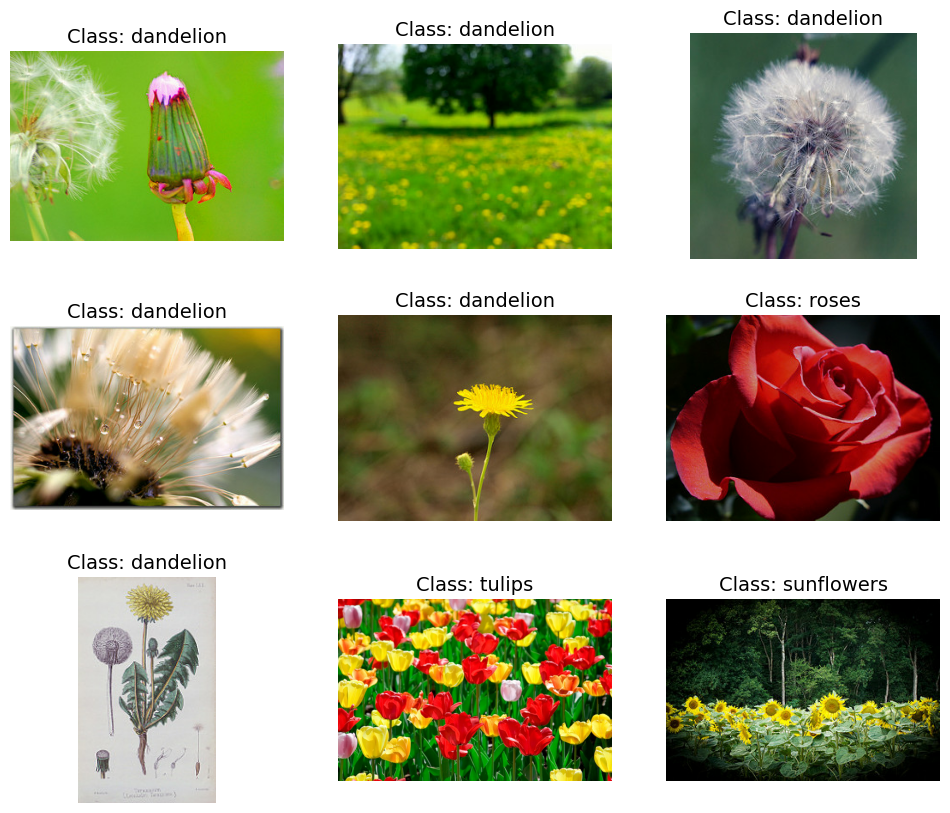

In [29]:
# extra code – displays the first 9 images in the validation set

plt.figure(figsize=(12, 10))
index = 0
for image, label in valid_set_raw.take(9):
    index += 1
    plt.subplot(3, 3, index)
    plt.imshow(image)
    plt.title(f"Class: {class_names[label]}")
    plt.axis("off")

plt.show()

In [30]:
train_set_raw

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

We can see that the `train_set_raw` variable is a `tf.data.Dataset` object. By the following code, we can take a single example from the training set and print its image shape, data type, label, class name, and the maximum and minimum pixel values. This helps us understand the structure of the dataset and the range of pixel values before we apply any preprocessing steps.

In [31]:
for image, label in train_set_raw.take(1):
    print(f"Image shape: {image.shape}, dtype: {image.dtype}")
    print(f"Label: {label.numpy()}, Class name: {class_names[label.numpy()]}")
    print(f"Max. of pixel values: {tf.reduce_max(image).numpy()}, Min. of pixel values: {tf.reduce_min(image).numpy()}")

Image shape: (240, 240, 3), dtype: <dtype: 'uint8'>
Label: 0, Class name: dandelion
Max. of pixel values: 255, Min. of pixel values: 0


All three datasets contain individual images. We need to batch them, but for this we first need to ensure they all have the same size, or else batching will not work. We can use a `Resizing` layer for this. We must also call the `tf.keras.applications.xception.preprocess_input()` function to preprocess the images appropriately for the Xception model. We will also add shuffling and prefetching to the training dataset.

In [ ]:
tf.keras.backend.clear_session()  # extra code – resets layer name counter

batch_size = 32

# defines a preprocessing pipeline that resizes the images to 224x224 pixels while maintaining the aspect ratio, and then applies the preprocessing function specific to the Xception model, which scales pixel values to the range [-1, 1]. The training set is then shuffled, batched, and prefetched for efficient training, while the validation and test sets are only preprocessed and batched without shuffling.
preprocess = tf.keras.Sequential([
    tf.keras.layers.Resizing(height=224, width=224, crop_to_aspect_ratio=True),
    tf.keras.layers.Lambda(tf.keras.applications.xception.preprocess_input)
])
train_set = train_set_raw.map(lambda X, y: (preprocess(X), y))
train_set = train_set.shuffle(1000, seed=42).batch(batch_size).prefetch(tf.data.AUTOTUNE)
valid_set = valid_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)
test_set = test_set_raw.map(lambda X, y: (preprocess(X), y)).batch(batch_size)

C:\Users\yuanh\AppData\Local\Temp\ipykernel_186064\2824403756.py:1: DeprecationWarning: The Tix Tk extension is unmaintained, and the tkinter.tix wrapper module is deprecated in favor of tkinter.ttk
  from tkinter.tix import AUTO



Let's take a look again at the first 9 images from the validation set: they're all 224x224 now, with values ranging from -1 to 1:

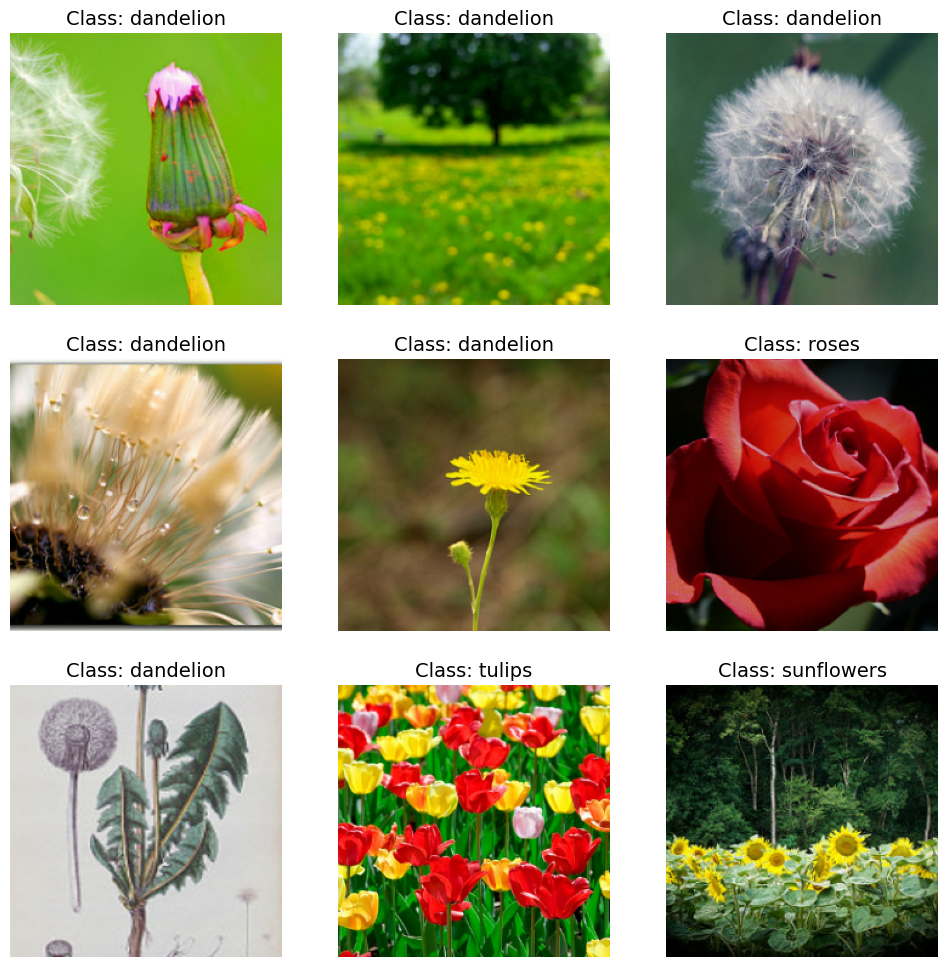

In [33]:
# extra code – displays the first 9 images in the first batch of valid_set

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        plt.imshow((X_batch[index] + 1) / 2)  # rescale to 0–1 for imshow()
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

**Data augmentation** is a powerful technique to artificially increase the size of your training dataset by applying random transformations to the input images, such as rotations, flips, zooms, and shifts. This helps to improve the generalization of the model and reduce overfitting.

In [34]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip(mode="horizontal", seed=42),
    tf.keras.layers.RandomRotation(factor=0.05, seed=42),
    tf.keras.layers.RandomContrast(factor=0.2, seed=42)
])

Try running the following cell multiple times to see different random data augmentations:

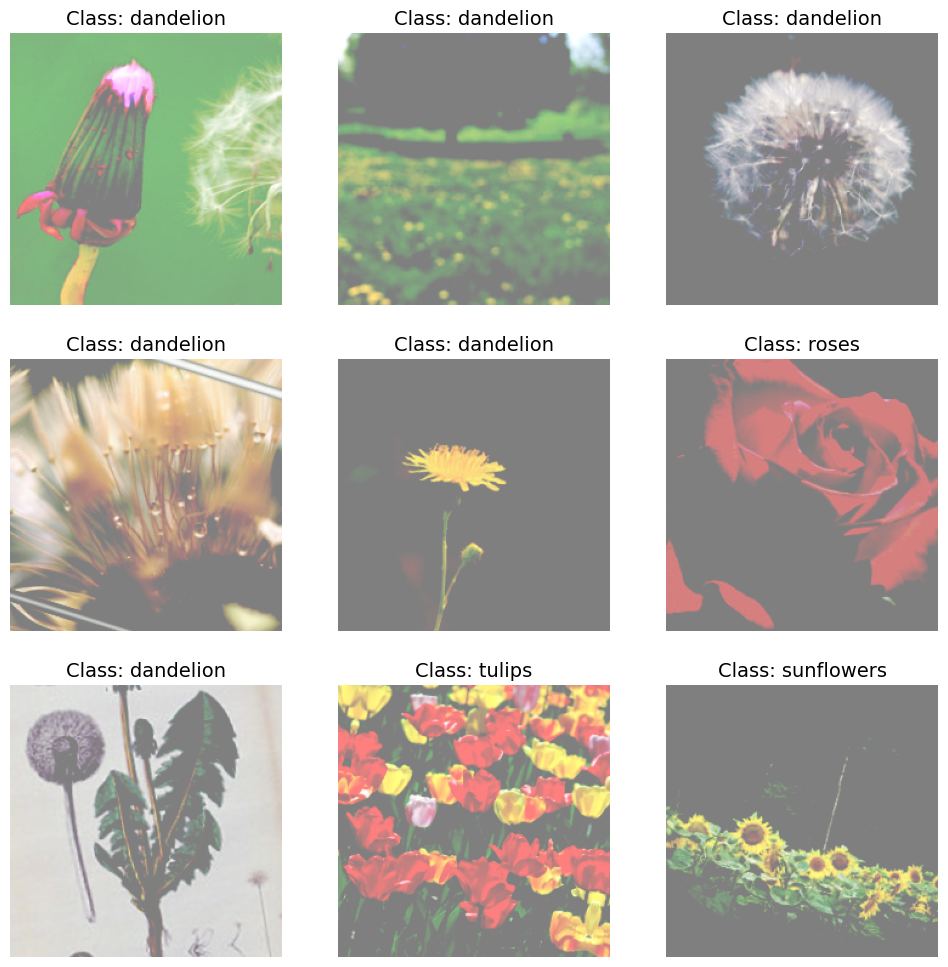

In [ ]:
# extra code – displays the same first 9 images, after augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    X_batch_augmented = data_augmentation(X_batch, training=True)
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # We must rescale the images to the 0-1 range for imshow(), and also
        # clip the result to that range, because data augmentation may
        # make some values go out of bounds (e.g., RandomContrast in this case).
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()

Keras provides a convenient `ImageDataGenerator` class that can be used for data augmentation. You can specify the types of transformations you want to apply, and it will generate augmented images on the fly during training. For example:


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# extra code – shows how to use the ImageDataGenerator for data augmentation
datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    zoom_range=0.2
)

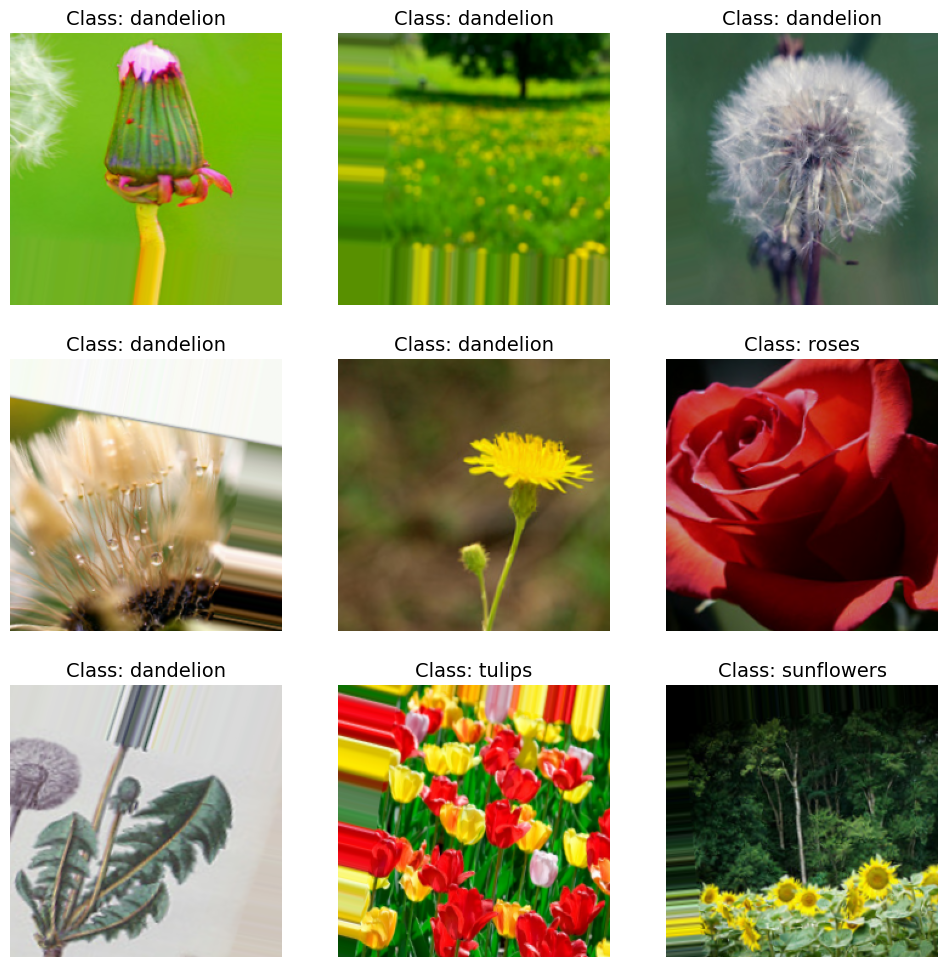

In [37]:
# extra code – displays the same first 9 images, after ImageDataGenerator augmentation

plt.figure(figsize=(12, 12))
for X_batch, y_batch in valid_set.take(1):
    # flow() returns an iterator; use next() to get the augmented NumPy array
    X_batch_augmented = next(datagen.flow(X_batch, batch_size=batch_size, shuffle=False))
    for index in range(9):
        plt.subplot(3, 3, index + 1)
        # Now X_batch_augmented is a NumPy array, so we can index individual images
        plt.imshow(np.clip((X_batch_augmented[index] + 1) / 2, 0, 1))
        plt.title(f"Class: {class_names[y_batch[index]]}")
        plt.axis("off")

plt.show()


Now let's load the pretrained model, without its top layers, and replace them with our own, for the flower classification task:

In [38]:
tf.random.set_seed(42)  # extra code – ensures reproducibility

# build the model by loading the Xception base model with pretrained ImageNet weights, excluding the top classification layer.
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)

# add a global average pooling layer and a dense output layer with softmax activation for classification into n_classes classes.
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg)

# create the final model by specifying the inputs and outputs
model = tf.keras.Model(inputs=base_model.input, outputs=output)

In [39]:
# freeze the base model layers 
for layer in base_model.layers:
    layer.trainable = False

Let's train the model for a few epochs, while keeping the base model weights fixed:

In [40]:
optimizer = tf.keras.optimizers.SGD(learning_rate=0.1, momentum=0.9)
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=3)

Epoch 1/3


86/86 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8089 - loss: 0.8067 - val_accuracy: 0.8421 - val_loss: 0.6156
Epoch 2/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.9186 - loss: 0.3072 - val_accuracy: 0.8584 - val_loss: 0.6094
Epoch 3/3
86/86 ━━━━━━━━━━━━━━━━━━━━ 161s 2s/step - accuracy: 0.9313 - loss: 0.2365 - val_accuracy: 0.8730 - val_loss: 0.5855


In [41]:
model.evaluate(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 0.8883 - loss: 0.4723


[0.4723314642906189, 0.888283371925354]

Investigate the layers of the base model.

In [42]:
for indices in zip(range(33), range(33, 66), range(66, 99), range(99, 132)):
    for idx in indices:
        print(f"{idx:3}: {base_model.layers[idx].name:22}", end="")
    print()

  0: input_layer_2          33: block4_pool            66: block8_sepconv1_act    99: block11_sepconv2_act  
  1: block1_conv1           34: batch_normalization_2  67: block8_sepconv1       100: block11_sepconv2      
  2: block1_conv1_bn        35: add_2                  68: block8_sepconv1_bn    101: block11_sepconv2_bn   
  3: block1_conv1_act       36: block5_sepconv1_act    69: block8_sepconv2_act   102: block11_sepconv3_act  
  4: block1_conv2           37: block5_sepconv1        70: block8_sepconv2       103: block11_sepconv3      
  5: block1_conv2_bn        38: block5_sepconv1_bn     71: block8_sepconv2_bn    104: block11_sepconv3_bn   
  6: block1_conv2_act       39: block5_sepconv2_act    72: block8_sepconv3_act   105: add_9                 
  7: block2_sepconv1        40: block5_sepconv2        73: block8_sepconv3       106: block12_sepconv1_act  
  8: block2_sepconv1_bn     41: block5_sepconv2_bn     74: block8_sepconv3_bn    107: block12_sepconv1      
  9: block2_sepconv

Now that the weights of our new top layers are not too bad, we can make the top part of the base model trainable again, and continue training, but with a lower learning rate:

In [43]:
# unfreeze the more layers of the base model
for layer in base_model.layers[56:]:
    layer.trainable = True

optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9) # reduce the learning rate for fine-tuning
model.compile(loss="sparse_categorical_crossentropy", optimizer=optimizer,
              metrics=["accuracy"])
history = model.fit(train_set, validation_data=valid_set, epochs=10)

Epoch 1/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 405s 5s/step - accuracy: 0.9084 - loss: 0.2768 - val_accuracy: 0.8711 - val_loss: 0.6194
Epoch 2/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 371s 4s/step - accuracy: 0.9833 - loss: 0.0548 - val_accuracy: 0.9038 - val_loss: 0.3173
Epoch 3/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 367s 4s/step - accuracy: 0.9967 - loss: 0.0169 - val_accuracy: 0.9147 - val_loss: 0.2661
Epoch 4/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 387s 4s/step - accuracy: 0.9964 - loss: 0.0109 - val_accuracy: 0.9111 - val_loss: 0.2886
Epoch 5/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 368s 4s/step - accuracy: 0.9985 - loss: 0.0050 - val_accuracy: 0.9129 - val_loss: 0.2985
Epoch 6/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 367s 4s/step - accuracy: 0.9989 - loss: 0.0036 - val_accuracy: 0.9129 - val_loss: 0.3138
Epoch 7/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 362s 4s/step - accuracy: 0.9971 - loss: 0.0087 - val_accuracy: 0.9056 - val_loss: 0.3089
Epoch 8/10
86/86 ━━━━━━━━━━━━━━━━━━━━ 360s 4s/step - accuracy: 0.9993 - loss: 0.0027 - val_accuracy: 0.9183 - v

In [44]:
model.evaluate(test_set)

12/12 ━━━━━━━━━━━━━━━━━━━━ 21s 2s/step - accuracy: 0.9401 - loss: 0.1952


[0.1951727569103241, 0.9400544762611389]

---
# Classification and Localization

**Note**: the code below used to reuse the optimizer from the previous model. This was fine in earlier versions of TensorFlow, but in more recent versions it can cause some issues, so I added a line to create a new optimizer here. Also, recent versions of Keras expect one metric per output, so I added the `"mse"` metric to the list.

In [ ]:
tf.random.set_seed(42)  # extra code – ensures reproducibility
base_model = tf.keras.applications.xception.Xception(weights="imagenet",
                                                     include_top=False)
avg = tf.keras.layers.GlobalAveragePooling2D()(base_model.output)
class_output = tf.keras.layers.Dense(n_classes, activation="softmax")(avg) # this is the original classification output layer
loc_output = tf.keras.layers.Dense(4)(avg) # added this line for localization output
model = tf.keras.Model(inputs=base_model.input,
                       outputs=[class_output, loc_output]) # modified to have two outputs: one for classification and one for localization
optimizer = tf.keras.optimizers.SGD(learning_rate=0.01, momentum=0.9)  # added this line
model.compile(loss=["sparse_categorical_crossentropy", "mse"],
              loss_weights=[0.8, 0.2],  # depends on what you care most about
              optimizer=optimizer, metrics=["accuracy", "mse"] # added metrics for both outputs
                )

In [ ]:
# extra code – fits the model using random target bounding boxes (in real life
#              you would need to create proper targets instead)

def add_random_bounding_boxes(images, labels):
    fake_bboxes = tf.random.uniform([tf.shape(images)[0], 4])
    return images, (labels, fake_bboxes)

fake_train_set = train_set.take(5).repeat(2).map(add_random_bounding_boxes)
model.fit(fake_train_set, epochs=2)

Epoch 1/2
10/10 [==============================] - 22s 1s/step - loss: 1.2157 - dense_1_loss: 1.4583 - dense_2_loss: 0.2450 - dense_1_accuracy: 0.4219 - dense_2_accuracy: 0.2594
Epoch 2/2
10/10 [==============================] - 15s 1s/step - loss: 0.7974 - dense_1_loss: 0.9474 - dense_2_loss: 0.1972 - dense_1_accuracy: 0.7594 - dense_2_accuracy: 0.2812


---
# Extra Material – How mAP Relates to Precision/Recall

In [ ]:
def maximum_precisions(precisions):
    return np.flip(np.maximum.accumulate(np.flip(precisions)))

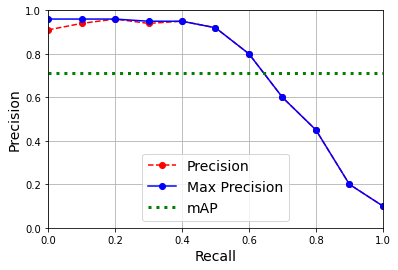

In [ ]:
recalls = np.linspace(0, 1, 11)

precisions = [0.91, 0.94, 0.96, 0.94, 0.95, 0.92, 0.80, 0.60, 0.45, 0.20, 0.10]
max_precisions = maximum_precisions(precisions)
mAP = max_precisions.mean()
plt.plot(recalls, precisions, "ro--", label="Precision")
plt.plot(recalls, max_precisions, "bo-", label="Max Precision")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.plot([0, 1], [mAP, mAP], "g:", linewidth=3, label="mAP")
plt.grid(True)
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower center")
plt.show()

Precision and recall are fundamental metrics used to evaluate the performance of object detection models. 
- Precision measures the accuracy of the model's positive predictions, defined as $P = \frac{TP}{TP + FP}$, where $TP$ is true positives and $FP$ is false positives. 
- Recall measures the model's ability to identify all relevant instances, defined as $R = \frac{TP}{TP + FN}$, where $FN$ is false negatives. 

As the detection confidence threshold changes, there is a natural trade-off: increasing recall typically leads to lower precision because the model becomes less "selective" and produces more false positives.

**Average Precision ($AP$)** summarizes the Precision-Recall (PR) curve into a single numerical value representing the area under the curve. To make this calculation robust against small fluctuations in the curve, researchers often use an "interpolated" precision. This involves taking the maximum precision found for any recall level greater than or equal to the current level. In the provided code, an 11-point interpolation is demonstrated, where the maximum precision is sampled at eleven equally spaced recall levels from 0 to 1.

**Mean Average Precision ($mAP$)** is the global metric used for multi-class object detection tasks. It is calculated by taking the arithmetic mean of the $AP$ scores across all $n$ classes in the dataset:

$$mAP = \frac{1}{n} \sum_{i=1}^{n} AP_i$$

This ensures that the model is evaluated fairly across all categories, preventing a high performance in one frequent class from masking poor performance in less frequent ones. In many benchmarks, $mAP$ is further refined by averaging over different Intersection over Union ($IoU$) thresholds to measure localization accuracy.

---
# Exercises

## 1. to 8.

1. These are the main advantages of a CNN over a fully connected DNN for image classification:
    * Because consecutive layers are only partially connected and because it heavily reuses its weights, a CNN has many fewer parameters than a fully connected DNN, which makes it much faster to train, reduces the risk of overfitting, and requires much less training data.
    * When a CNN has learned a kernel that can detect a particular feature, it can detect that feature anywhere in the image. In contrast, when a DNN learns a feature in one location, it can detect it only in that particular location. Since images typically have very repetitive features, CNNs are able to generalize much better than DNNs for image processing tasks such as classification, using fewer training examples.
    * Finally, a DNN has no prior knowledge of how pixels are organized; it does not know that nearby pixels are close. A CNN's architecture embeds this prior knowledge. Lower layers typically identify features in small areas of the images, while higher layers combine the lower-level features into larger features. This works well with most natural images, giving CNNs a decisive head start compared to DNNs.


2. Let's compute how many parameters the CNN has.
    * Since its first convolutional layer has 3 × 3 kernels, and the input has three channels (red, green, and blue), each feature map has 3 × 3 × 3 weights, plus a bias term. That's 28 parameters per feature map. Since this first convolutional layer has 100 feature maps, it has a total of 2,800 parameters. The second convolutional layer has 3 × 3 kernels and its input is the set of 100 feature maps of the previous layer, so each feature map has 3 × 3 × 100 = 900 weights, plus a bias term. Since it has 200 feature maps, this layer has 901 × 200 = 180,200 parameters. Finally, the third and last convolutional layer also has 3 × 3 kernels, and its input is the set of 200 feature maps of the previous layers, so each feature map has 3 × 3 × 200 = 1,800 weights, plus a bias term. Since it has 400 feature maps, this layer has a total of 1,801 × 400 = 720,400 parameters. All in all, the CNN has 2,800 + 180,200 + 720,400 =  903,400 parameters.<br/>
    * Now let's compute how much RAM this neural network will require (at least) when making a prediction for a single instance. First let's compute the feature map size for each layer. Since we are using a stride of 2 and `"same"` padding, the horizontal and vertical dimensions of the feature maps are divided by 2 at each layer (rounding up if necessary). So, as the input channels are 200 × 300 pixels, the first layer's feature maps are 100 × 150, the second layer's feature maps are 50 × 75, and the third layer's feature maps are 25 × 38. Since 32 bits is 4 bytes and the first convolutional layer has 100 feature maps, this first layer takes up 4 × 100 × 150 × 100 = 6 million bytes (6 MB). The second layer takes up 4 × 50 × 75 × 200 = 3 million bytes (3 MB). Finally, the third layer takes up 4 × 25 × 38 × 400 = 1,520,000 bytes (about 1.5 MB). However, once a layer has been computed, the memory occupied by the previous layer can be released, so if everything is well optimized, only 6 + 3 = 9 million bytes (9 MB) of RAM will be required (when the second layer has just been computed, but the memory occupied by the first layer has not been released yet). But wait, you also need to add the memory occupied by the CNN's parameters! We computed earlier that it has 903,400 parameters, each using up 4 bytes, so this adds 3,613,600 bytes (about 3.6 MB). The total RAM required is therefore (at least) 12,613,600 bytes (about 12.6 MB).<br/>
    * Lastly, let's compute the minimum amount of RAM required when training the CNN on a mini-batch of 50 images. During training TensorFlow uses backpropagation, which requires keeping all values computed during the forward pass until the reverse pass begins. So we must compute the total RAM required by all layers for a single instance and multiply that by 50. At this point, let's start counting in megabytes rather than bytes. We computed before that the three layers require respectively 6, 3, and 1.5 MB for each instance. That's a total of 10.5 MB per instance, so for 50 instances the total RAM required is 525 MB. Add to that the RAM required by the input images, which is 50 × 4 × 200 × 300 × 3 = 36 million bytes (36 MB), plus the RAM required for the model parameters, which is about 3.6 MB (computed earlier), plus some RAM for the gradients (we will neglect this since it can be released gradually as backpropagation goes down the layers during the reverse pass). We are up to a total of roughly 525 + 36 + 3.6 = 564.6 MB, and that's really an optimistic bare minimum.


3. If your GPU runs out of memory while training a CNN, here are five things you could try to solve the problem (other than purchasing a GPU with more RAM):
    * Reduce the mini-batch size.
    * Reduce dimensionality using a larger stride in one or more layers.
    * Remove one or more layers.
    * Use 16-bit floats instead of 32-bit floats.
    * Distribute the CNN across multiple devices.


4. A max pooling layer has no parameters at all, whereas a convolutional layer has quite a few (see the previous questions).


5. A **local response normalization (LRN) layer** makes the neurons that most strongly activate inhibit neurons at the same location but in neighboring feature maps, which encourages different feature maps to specialize and pushes them apart, forcing them to explore a wider range of features. It is typically used in the lower layers to have a larger pool of low-level features that the upper layers can build upon.



**局部響應歸一化 (LRN) 層**

1. **Core mechanism:** The LRN layer causes neurons that activate most strongly at a given spatial location to suppress other neurons at the same spatial location but in **adjacent feature maps**.
    * This means LRN operates **across channels**, not across the spatial dimensions of a single feature map. It looks at the activations from multiple neighboring feature maps at each pixel location and normalizes them.
    * This suppression mechanism creates a form of **local competition**, allowing a strong response in one channel to partly “suppress” responses in nearby channels.

2. **Purpose and benefits:**
    * **Encourage feature map specialization:** Through this suppression mechanism, the LRN layer pushes different feature maps to learn and focus on different, unique features. If multiple feature maps try to detect very similar patterns, competition forces some maps to explore other distinct patterns.
    * **Expand feature exploration:** This “repelling” effect lets the network explore a wider range of features, rather than letting many feature maps redundantly learn the same information.
    * **Enrich low-level feature banks:** LRN is usually applied in the **lower layers** of a convolutional neural network. The goal is to build a richer, more diverse set of low-level features early, providing a stronger foundation for higher-level convolutional layers to build more complex features.

In short, the LRN layer aims to enhance feature map diversity and specialization through local competition, especially in the early stages of the network.

Historically, LRN was popularized by the AlexNet architecture, which used it to improve performance on the ImageNet classification task. However, in more recent architectures, LRN has been largely replaced by batch normalization and other normalization techniques, which have been found to be more effective and easier to train.

As such, tf.keras.layers does not have a built-in LocalResponseNormalization layer.

If you were to implement it from scratch, it would involve normalizing the activations across neighboring feature maps. However, it's generally not recommended for modern CNNs due to the superior performance of Batch Normalization.

6. The main innovations in AlexNet compared to LeNet-5 are that it is much larger and deeper, and it stacks convolutional layers directly on top of each other, instead of stacking a pooling layer on top of each convolutional layer. The main innovation in GoogLeNet is the introduction of _inception modules_, which make it possible to have a much deeper net than previous CNN architectures, with fewer parameters. ResNet's main innovation is the introduction of skip connections, which make it possible to go well beyond 100 layers. Arguably, its simplicity and consistency are also rather innovative. SENet's main innovation was the idea of using an SE block (a two-layer dense network) after every inception module in an inception network or every residual unit in a ResNet to recalibrate the relative importance of feature maps. Xception's main innovation was the use of depthwise separable convolutional layers, which look at spatial patterns and depthwise patterns separately. Lastly, EfficientNet's main innotation was the compound scaling method, to efficiently scale a model to a larger compute budget.


**Inception module**
An inception module is a building block for convolutional neural networks that allows the network to learn features at multiple scales simultaneously. It consists of several parallel convolutional layers with different kernel sizes (e.g., 1x1, 3x3, 5x5) and a max pooling layer, all operating on the same input. The outputs of these layers are then concatenated together to form the output of the inception module.
```python
def inception_module(input_tensor, filters):
    # 1x1 convolution
    conv_1x1 = Conv2D(filters, (1, 1), padding='same', activation='relu')(input_tensor)
    
    # 3x3 convolution
    conv_3x3 = Conv2D(filters, (3, 3), padding='same', activation='relu')(input_tensor)
    
    # 5x5 convolution
    conv_5x5 = Conv2D(filters, (5, 5), padding='same', activation='relu')(input_tensor)
    
    # Max pooling followed by a 1x1 convolution
    max_pool = MaxPooling2D((3, 3), strides=(1, 1), padding='same')(input_tensor)
    max_pool_conv = Conv2D(filters, (1, 1), padding='same', activation='relu')(max_pool)
    
    # Concatenate all the outputs
    output = concatenate([conv_1x1, conv_3x3, conv_5x5, max_pool_conv], axis=-1)
    
    return output
```

A `1x1` convolution is particularly noteworthy here; it doesn't expand the receptive field spatially but instead operates across the channel dimension. Its primary role is to reduce the number of feature maps (channels) from the input `max_pool` tensor, thereby significantly reducing computational complexity and the number of parameters in subsequent layers. Despite its small kernel, it introduces non-linearity through the `activation='relu'` function, allowing the network to learn more complex patterns while controlling dimensionality.

By applying this `1x1` convolution with `padding='same'`, the layer ensures that the spatial dimensions (height and width) of the input `max_pool` tensor are preserved in the output `max_pool_conv` tensor, while its depth (number of channels) is transformed to the specified `filters` count. This combination of pooling and subsequent `1x1` convolution is a common pattern in Inception architectures, allowing for efficient feature aggregation and dimensionality management.

7. Fully convolutional networks are neural networks composed exclusively of convolutional and pooling layers. FCNs can efficiently process images of any width and height (at least above the minimum size). They are most useful for object detection and semantic segmentation because they only need to look at the image once (instead of having to run a CNN multiple times on different parts of the image). If you have a CNN with some dense layers on top, you can convert these dense layers to convolutional layers to create an FCN: just replace the lowest dense layer with a convolutional layer with a kernel size equal to the layer's input size, with one filter per neuron in the dense layer, and using `"valid"` padding. Generally the stride should be 1, but you can set it to a higher value if you want. The activation function should be the same as the dense layer's. The other dense layers should be converted the same way, but using 1 × 1 filters. It is actually possible to convert a trained CNN this way by appropriately reshaping the dense layers' weight matrices.


A **Fully Convolutional Network (FCN)** is a type of neural network that is built entirely from convolutional and pooling layers, without any dense (fully connected) layers at the end. This architectural design allows FCNs to process input images of arbitrary spatial dimensions (width and height), as long as they are above a minimum size. This flexibility is a significant advantage over traditional Convolutional Neural Networks (CNNs) that typically require a fixed input size due to their dense layers.

FCNs are particularly well-suited for computer vision tasks like *object detection* and *semantic segmentation*. In these applications, the goal is often to make per-pixel predictions or predictions that require retaining spatial information. Since FCNs operate solely with convolutional operations, they can maintain and refine spatial information throughout the network, leading to dense output maps rather than single class probabilities. Their efficiency stems from the ability to process an entire image in a single forward pass, eliminating the need to run the network multiple times on different regions of an image, which is common in older object detection approaches.

A key concept mentioned is how to transform a standard CNN (which typically ends with dense layers for classification) into an FCN. This conversion involves replacing each dense layer with an equivalent convolutional layer. For the lowest dense layer in the original CNN, it is replaced by a `Conv2D` layer whose kernel size matches the spatial dimensions of its input (the feature map coming from the preceding convolutional/pooling layers). The number of filters in this new convolutional layer should be equal to the number of neurons in the original dense layer, and `"valid"` padding is used. The stride is generally set to 1, but can be increased if further spatial reduction is desired. Subsequent dense layers are then replaced by `Conv2D` layers using $1 \times 1$ kernels, which effectively perform a weighted sum across the channels at each spatial location, similar to a dense layer operating on a single pixel. Crucially, the activation function of these new convolutional layers should be the same as their original dense counterparts. This conversion can even be applied to a *trained* CNN by appropriately reshaping the weight matrices of the dense layers into convolutional kernels.

```python
# Example of converting a dense layer to a convolutional layer
# Assume we have a dense layer with 128 neurons and an input feature map of size (8, 8, 64)
# The dense layer has 128 neurons, so we will create a Conv2D layer with 128 filters
# The kernel size will be (8, 8) to cover the entire spatial dimensions of the input feature map
conv_layer = Conv2D(filters=128, kernel_size=(8, 8), padding='valid', activation='relu')
```

This code snippet illustrates the conversion of a conceptual dense layer into a `Conv2D` layer suitable for an FCN. If a dense layer had 128 neurons and was receiving input from a feature map of size (8, 8, 64), it would typically operate on a flattened version of this input. To convert it into a convolutional equivalent, a `Conv2D` layer is created with 128 filters (corresponding to the 128 neurons). The `kernel_size` is set to `(8, 8)` to match the spatial dimensions of the input feature map, effectively making each filter span the entire input area. `padding='valid'` ensures no extra padding is added, resulting in an output feature map of size (1, 1, 128), which is the spatial equivalent of the 128 outputs from the original dense layer. The `activation='relu'` is maintained from the original dense layer.

8. The main technical difficulty of semantic segmentation is the fact that a lot of the spatial information gets lost in a CNN as the signal flows through each layer, especially in pooling layers and layers with a stride greater than 1. This spatial information needs to be restored somehow to accurately predict the class of each pixel.

---
## 9. High Accuracy CNN for MNIST
_Exercise: Build your own CNN from scratch and try to achieve the highest possible accuracy on MNIST._

The following model uses 2 convolutional layers, followed by 1 pooling layer, then dropout 25%, then a dense layer, another dropout layer but with 50% dropout, and finally the output layer. It reaches about 99.2% accuracy on the test set. This places this model roughly in the top 20% in the [MNIST Kaggle competition](https://www.kaggle.com/c/digit-recognizer/) (if we ignore the models with an accuracy greater than 99.79% which were most likely trained on the test set, as explained by Chris Deotte in [this post](https://www.kaggle.com/c/digit-recognizer/discussion/61480)). Can you do better? To reach 99.5 to 99.7% accuracy on the test set, you need to add image augmentation, batch norm, use a learning schedule such as 1-cycle, and possibly create an ensemble.

In [ ]:
mnist = tf.keras.datasets.mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = mnist
X_train_full = X_train_full / 255.
X_test = X_test / 255.
X_train, X_valid = X_train_full[:-5000], X_train_full[-5000:]
y_train, y_valid = y_train_full[:-5000], y_train_full[-5000:]

11501568/11490434 [==============================] - 0s 0us/step


In [ ]:

X_train = X_train[..., np.newaxis]
X_valid = X_valid[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
tf.keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Conv2D(32, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.Conv2D(64, kernel_size=3, padding="same",
                           activation="relu", kernel_initializer="he_normal"),
    tf.keras.layers.MaxPool2D(),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dropout(0.25),
    tf.keras.layers.Dense(128, activation="relu",
                          kernel_initializer="he_normal"),
    tf.keras.layers.Dropout(0.5),
    tf.keras.layers.Dense(10, activation="softmax")
])
model.compile(loss="sparse_categorical_crossentropy", optimizer="nadam",
              metrics=["accuracy"])

model.fit(X_train, y_train, epochs=10, validation_data=(X_valid, y_valid))
model.evaluate(X_test, y_test)

Epoch 1/10
1719/1719 [==============================] - 25s 14ms/step - loss: 0.1943 - accuracy: 0.9415 - val_loss: 0.0431 - val_accuracy: 0.9884
Epoch 2/10
1719/1719 [==============================] - 22s 13ms/step - loss: 0.0807 - accuracy: 0.9754 - val_loss: 0.0454 - val_accuracy: 0.9882
Epoch 3/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.0609 - accuracy: 0.9808 - val_loss: 0.0361 - val_accuracy: 0.9890
Epoch 4/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.0506 - accuracy: 0.9841 - val_loss: 0.0339 - val_accuracy: 0.9910
Epoch 5/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.0407 - accuracy: 0.9869 - val_loss: 0.0330 - val_accuracy: 0.9928
Epoch 6/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.0350 - accuracy: 0.9889 - val_loss: 0.0383 - val_accuracy: 0.9916
Epoch 7/10
1719/1719 [==============================] - 21s 12ms/step - loss: 0.0326 - accuracy: 0.9892 - val_loss: 0.0356 -

[0.030648918822407722, 0.9914000034332275]

---
## 10.  Use transfer learning for large image classification

_Exercise: Use transfer learning for large image classification, going through these steps:_

* _Create a training set containing at least 100 images per class. For example, you could classify your own pictures based on the location (beach, mountain, city, etc.), or alternatively you can use an existing dataset (e.g., from TensorFlow Datasets)._
* _Split it into a training set, a validation set, and a test set._
* _Build the input pipeline, including the appropriate preprocessing operations, and optionally add data augmentation._
* _Fine-tune a pretrained model on this dataset._

See the Flowers example above.

## 11.
_Exercise: Go through TensorFlow's [Style Transfer tutorial](https://homl.info/styletuto). It is a fun way to generate art using Deep Learning._


Simply open the Colab and follow its instructions.